In [1]:
!nvidia-smi

Wed Jul 15 02:50:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.74                 KMD Version: 610.74        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   59C    P0             32W /   80W |    1703MiB /   6144MiB |      7%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, precision_recall_fscore_support

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3060 Laptop GPU'

In [4]:
torch.cuda.is_available()

True

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Análisis Exploratorio de Datos

In [6]:
from pathlib import Path

# Definimos las rutas para cada conjunto de datos del dataset de kaggle:  train, valid y test

DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

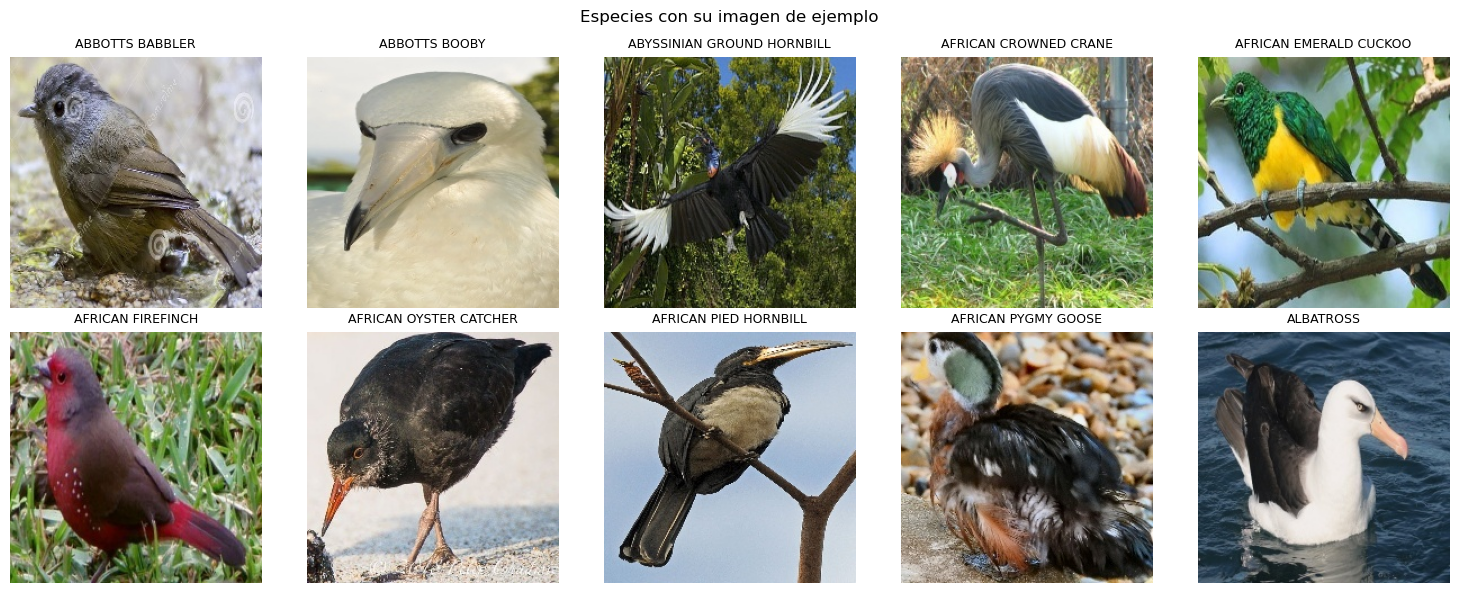

In [ ]:
especies = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
n_muestra = 8 

# se eligen especies aleatorias para mostrar del conjunto train
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i, especie in enumerate(especies[:10]):
    img_path = next((TRAIN_DIR / especie).glob("*.jpg"))
    axes[i].imshow(Image.open(img_path))
    axes[i].set_title(especie, fontsize=9)
    axes[i].axis("off")
plt.suptitle("Especies con su imagen de ejemplo")
plt.tight_layout()
plt.show()

In [8]:

# definimos una funcion para contar el numero de imagenes que existen por especie en cada conjunto de datos
def contar_imagenes_por_especie(split_dir):
    conteo = {}
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            conteo[class_dir.name] = len(list(class_dir.glob("*.jpg")))
    return pd.Series(conteo)

conteo_train = contar_imagenes_por_especie(TRAIN_DIR)
conteo_valid = contar_imagenes_por_especie(VALID_DIR)
conteo_test = contar_imagenes_por_especie(TEST_DIR)


# imprimimos el total de imagenes en cada conjunto de datos y el numero de especies
print(f"Total imágenes train: {conteo_train.sum()}")
print(f"Total imágenes valid: {conteo_valid.sum()}")
print(f"Total imágenes test:  {conteo_test.sum()}")
print(f"Número de especies: {len(conteo_train)}")

Total imágenes train: 3208
Total imágenes valid: 100
Total imágenes test:  100
Número de especies: 20


Una vez obtenido el conteo de imágenes por subconjunto, filtramos el set de train para extraer la ave con la mayor cantidad de imagenes

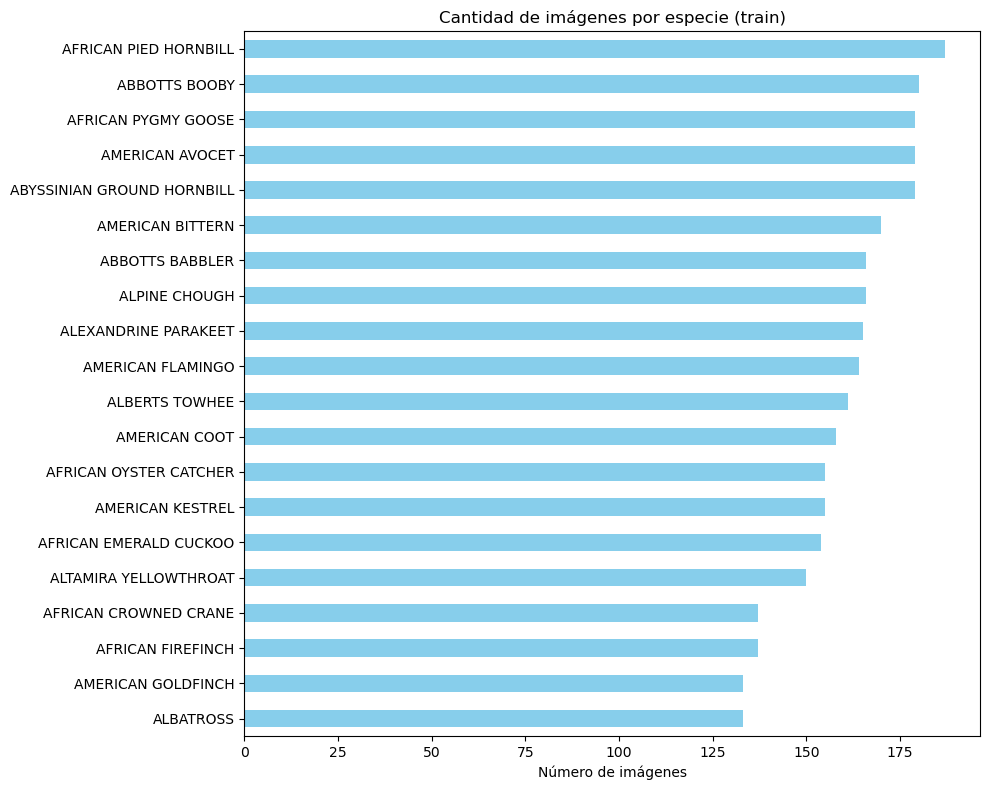

In [9]:
conteo_train.sort_values().plot(kind="barh", figsize=(10, 8), color="skyblue")
plt.title("Cantidad de imágenes por especie (train)")
plt.xlabel("Número de imágenes")
plt.tight_layout()
plt.show()

In [10]:
# obtenemos el tamaño de las imagenes para ver si es necesario redimensionarlas antes de entrenar el modelo
tamanos = []
for class_dir in list(TRAIN_DIR.iterdir())[:5]:
    for img_path in list(class_dir.glob("*.jpg"))[:5]:
        with Image.open(img_path) as im:
            tamanos.append(im.size)

pd.DataFrame(tamanos, columns=["width", "height"]).describe()

,width,height
count,25.0,25.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


Con el dataset normalizado, el análisis previo reveló que algunas especies de aves tienen significativamente más imágenes que otras, para lograr evitar que el modelo sea sesgado y que solo acierte en las que tiene más imagenes, se debe integrar un balanceo de clases. Así el modelo tiene una mucho mayor precisión en todas las especies por igual y tiene una menor función de perdida

In [11]:
conteos = conteo_train[especies].values
class_weights = conteos.sum() / (len(especies) * conteos)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# imprimimos los pesos de cada clase
for nombre, peso in zip(especies, class_weights):
    print(f"{nombre}: {peso:.3f}")


ABBOTTS BABBLER: 0.966
ABBOTTS BOOBY: 0.891
ABYSSINIAN GROUND HORNBILL: 0.896
AFRICAN CROWNED CRANE: 1.171
AFRICAN EMERALD CUCKOO: 1.042
AFRICAN FIREFINCH: 1.171
AFRICAN OYSTER CATCHER: 1.035
AFRICAN PIED HORNBILL: 0.858
AFRICAN PYGMY GOOSE: 0.896
ALBATROSS: 1.206
ALBERTS TOWHEE: 0.996
ALEXANDRINE PARAKEET: 0.972
ALPINE CHOUGH: 0.966
ALTAMIRA YELLOWTHROAT: 1.069
AMERICAN AVOCET: 0.896
AMERICAN BITTERN: 0.944
AMERICAN COOT: 1.015
AMERICAN FLAMINGO: 0.978
AMERICAN GOLDFINCH: 1.206
AMERICAN KESTREL: 1.035


## Feature Engineering 

In [12]:
from torchvision.models import resnet50

In [13]:
preprocessing = transforms.Compose([ 
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

transformamos la imagen para que tenga el tamaño del modelo preentrenado

In [14]:
train_folder = ImageFolder(TRAIN_DIR, transform=preprocessing)  # Train
val_folder = ImageFolder(VALID_DIR, transform=preprocessing)    # Val
test_folder = ImageFolder(TEST_DIR, transform=preprocessing)    # Test

class_names = train_folder.classes
num_classes = len(class_names)
print(f"Clases ({num_classes}): {class_names}")

Clases (20): ['ABBOTTS BABBLER', 'ABBOTTS BOOBY', 'ABYSSINIAN GROUND HORNBILL', 'AFRICAN CROWNED CRANE', 'AFRICAN EMERALD CUCKOO', 'AFRICAN FIREFINCH', 'AFRICAN OYSTER CATCHER', 'AFRICAN PIED HORNBILL', 'AFRICAN PYGMY GOOSE', 'ALBATROSS', 'ALBERTS TOWHEE', 'ALEXANDRINE PARAKEET', 'ALPINE CHOUGH', 'ALTAMIRA YELLOWTHROAT', 'AMERICAN AVOCET', 'AMERICAN BITTERN', 'AMERICAN COOT', 'AMERICAN FLAMINGO', 'AMERICAN GOLDFINCH', 'AMERICAN KESTREL']


In [15]:
# Generadores
train_loader = DataLoader(train_folder, batch_size=32, shuffle=True)
val_loader = DataLoader(val_folder, batch_size=32)
test_loader = DataLoader(test_folder, batch_size=32)

In [16]:
model = resnet50(weights="IMAGENET1K_V1")  # llamamos al modelo preentrenado con los pesos de imagenet el cual contiene imagenes de aves que nos servira para hacer el transfer learning
model.to(device)  # lo movemos a la gpu

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
# congelamos los pesos de la red neuronal
for params in model.parameters():
    params.requires_grad = False

In [18]:
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
# Reemplazar la capa final de la red por una nueva, con salida = num_classes
model.fc.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor) # usamos el balanceo de clases que se hizo antes para ponderar la perdida de cada clase
optimizer = SGD(params=model.fc.parameters(), lr=1e-3, momentum=0.9) # solo entrenamos la capa final de la red, y definimos su learning rate, y momentum para que no se estanque en un minimo local

In [20]:
# Training loop
model.to(device)  # Mover el modelo a la GPU
train_losses = []
val_losses = []
val_accuracies = []
epochs = 10  # Seteamos un número de épocas

for epoch in range(epochs):
    # --- Entrenamiento ---
    model.train()  # Modo entrenamiento
    train_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Montar los datos en la GPU
        optimizer.zero_grad()          # Limpiar los gradientes
        y_prob = model(inputs)         # Forward pass
        loss = loss_fn(y_prob, labels) # Calcular la loss
        loss.backward()                # Backward pass
        optimizer.step()               # Actualizar los pesos
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validación ---
    model.eval()  # Modo evaluación
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            y_prob = model(inputs)
            loss = loss_fn(y_prob, labels)
            val_loss += loss.item()

            preds = y_prob.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} - train_loss: {avg_train_loss:.4f} - "
          f"val_loss: {avg_val_loss:.4f} - val_acc: {val_acc:.4f}")


Epoch 1/10 - train_loss: 2.0029 - val_loss: 0.9476 - val_acc: 0.9500
Epoch 2/10 - train_loss: 0.8676 - val_loss: 0.4404 - val_acc: 0.9500
Epoch 3/10 - train_loss: 0.5681 - val_loss: 0.2706 - val_acc: 0.9800
Epoch 4/10 - train_loss: 0.4346 - val_loss: 0.2087 - val_acc: 0.9800
Epoch 5/10 - train_loss: 0.3617 - val_loss: 0.1700 - val_acc: 0.9800
Epoch 6/10 - train_loss: 0.3196 - val_loss: 0.1448 - val_acc: 0.9900
Epoch 7/10 - train_loss: 0.2759 - val_loss: 0.1379 - val_acc: 0.9900
Epoch 8/10 - train_loss: 0.2518 - val_loss: 0.1211 - val_acc: 0.9900
Epoch 9/10 - train_loss: 0.2359 - val_loss: 0.1042 - val_acc: 0.9900
Epoch 10/10 - train_loss: 0.2213 - val_loss: 0.1020 - val_acc: 0.9900


### Curvas de entrenamiento

<Axes: >

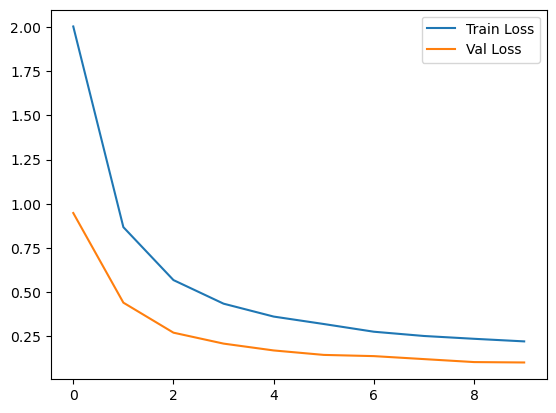

In [21]:
sns.lineplot(x = range(epochs), y= train_losses, label = "Train Loss")
sns.lineplot(x = range(epochs), y= val_losses, label = "Val Loss")

In [22]:
# Evaluamos el modelo entrenado sobre el set de test, que no fue usado ni el de entrenamiento ni el de validación para ver que tan bien generaliza el modelo a datos que no ha visto, entre las especies que se entrenaron

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        output = model(data)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.numpy())

import numpy as np
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

test_accuracy = (all_preds == all_targets).mean()
print(f"Accuracy en test: {test_accuracy}")


Accuracy en test: 0.99


### Métricas y evaluación de resultados

In [23]:
reporte = classification_report(all_targets, all_preds, target_names=class_names, digits=3)
print(reporte)

                            precision    recall  f1-score   support

           ABBOTTS BABBLER      1.000     1.000     1.000         5
             ABBOTTS BOOBY      1.000     0.800     0.889         5
ABYSSINIAN GROUND HORNBILL      1.000     1.000     1.000         5
     AFRICAN CROWNED CRANE      1.000     1.000     1.000         5
    AFRICAN EMERALD CUCKOO      1.000     1.000     1.000         5
         AFRICAN FIREFINCH      1.000     1.000     1.000         5
    AFRICAN OYSTER CATCHER      1.000     1.000     1.000         5
     AFRICAN PIED HORNBILL      1.000     1.000     1.000         5
       AFRICAN PYGMY GOOSE      1.000     1.000     1.000         5
                 ALBATROSS      0.833     1.000     0.909         5
            ALBERTS TOWHEE      1.000     1.000     1.000         5
      ALEXANDRINE PARAKEET      1.000     1.000     1.000         5
             ALPINE CHOUGH      1.000     1.000     1.000         5
     ALTAMIRA YELLOWTHROAT      1.000     1.000

vemos que el accuracy es casi perfecto por lo tanto deberia estar detectando de manera muy precisa la imagen que se le consulte indicando correctamente al ave que pertenece, incluso con las aves que presentan menos fotos, se verificara con una prueba individual en la carpeta de "images to predict" que el mismo dataset nos indica

In [24]:
predict_dir = DATA_DIR / "images to predict" 

predict_paths = sorted(predict_dir.glob("*.jpg"))
print(f"Imágenes para predecir: {len(predict_paths)}")

Imágenes para predecir: 6


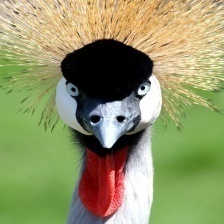

In [25]:
# capturamos todas las imagenees que se encuentran en la carpeta de predicción
img_test_path = predict_paths[0]
img_test = Image.open(img_test_path).convert("RGB")
img_test.thumbnail(size=(256, 256))

img_test_path2 = predict_paths[1]
img_test2 = Image.open(img_test_path2).convert("RGB")
img_test2.thumbnail(size=(256, 256))

img_test_path3 = predict_paths[2]
img_test3 = Image.open(img_test_path3).convert("RGB")
img_test3.thumbnail(size=(256, 256))

img_test_path4 = predict_paths[3]
img_test4 = Image.open(img_test_path4).convert("RGB")
img_test4.thumbnail(size=(256, 256))

img_test_path5 = predict_paths[4]
img_test5 = Image.open(img_test_path5).convert("RGB")
img_test5.thumbnail(size=(256, 256))

img_test_path6 = predict_paths[5]
img_test6 = Image.open(img_test_path6).convert("RGB")
img_test6.thumbnail(size=(256, 256))

img_test2

In [26]:
batch_test = preprocessing(img_test).unsqueeze(0).to(device)
batch_test2 = preprocessing(img_test2).unsqueeze(0).to(device)
batch_test3 = preprocessing(img_test3).unsqueeze(0).to(device)
batch_test4 = preprocessing(img_test4).unsqueeze(0).to(device)
batch_test5 = preprocessing(img_test5).unsqueeze(0).to(device)
batch_test6 = preprocessing(img_test6).unsqueeze(0).to(device)


### imagen 1

In [27]:
y_prob = model(batch_test)
y_prob_softmax = nn.Softmax(dim=1)(y_prob).cpu().detach().numpy()
df_probs = pd.DataFrame(y_prob_softmax, columns=class_names, index=[img_test_path.name])
df_probs.T.sort_values(by=img_test_path.name, ascending=False).head(5)

,1.jpg
AFRICAN CROWNED CRANE,0.993138
AFRICAN FIREFINCH,0.002084
ABBOTTS BOOBY,0.000979
ALEXANDRINE PARAKEET,0.000509
ABYSSINIAN GROUND HORNBILL,0.000457


### imagen 2

In [28]:
y_prob2 = model(batch_test2)
y_prob_softmax2 = nn.Softmax(dim=1)(y_prob2).cpu().detach().numpy()
df_probs2 = pd.DataFrame(y_prob_softmax2, columns=class_names, index=[img_test_path2.name])
df_probs2.T.sort_values(by=img_test_path2.name, ascending=False).head(5)

,2.jpg
AFRICAN CROWNED CRANE,0.933843
ALEXANDRINE PARAKEET,0.011591
ABBOTTS BOOBY,0.010471
AFRICAN PYGMY GOOSE,0.006153
AMERICAN FLAMINGO,0.005941


### imagen  3

In [29]:
y_prob3 = model(batch_test3)
y_prob_softmax3 = nn.Softmax(dim=1)(y_prob3).cpu().detach().numpy()
df_probs3 = pd.DataFrame(y_prob_softmax3, columns=class_names, index=[img_test_path3.name])
df_probs3.T.sort_values(by=img_test_path3.name, ascending=False).head(5)

,3.jpg
AFRICAN CROWNED CRANE,0.976154
ABYSSINIAN GROUND HORNBILL,0.010808
ABBOTTS BOOBY,0.002166
AMERICAN BITTERN,0.002063
AFRICAN PIED HORNBILL,0.002016


### imagen 4

In [30]:
y_prob4 = model(batch_test4)
y_prob_softmax4 = nn.Softmax(dim=1)(y_prob4).cpu().detach().numpy()
df_probs4 = pd.DataFrame(y_prob_softmax4, columns=class_names, index=[img_test_path4.name])
df_probs4.T.sort_values(by=img_test_path4.name, ascending=False).head(5)

,4.jpg
AFRICAN CROWNED CRANE,0.997838
ABBOTTS BOOBY,0.000761
ABYSSINIAN GROUND HORNBILL,0.000388
AMERICAN FLAMINGO,0.000199
AMERICAN AVOCET,0.000129


### imagen 5

In [31]:
y_prob5 = model(batch_test5)
y_prob_softmax5 = nn.Softmax(dim=1)(y_prob5).cpu().detach().numpy()
df_probs5 = pd.DataFrame(y_prob_softmax5, columns=class_names, index=[img_test_path5.name])
df_probs5.T.sort_values(by=img_test_path5.name, ascending=False).head(5)

,5.jpg
AFRICAN CROWNED CRANE,0.996970
ABBOTTS BOOBY,0.000819
AMERICAN AVOCET,0.000285
AFRICAN FIREFINCH,0.000274
AMERICAN FLAMINGO,0.000244


### imagen 6

In [32]:
y_prob6 = model(batch_test6)
y_prob_softmax6 = nn.Softmax(dim=1)(y_prob6).cpu().detach().numpy()
df_probs6 = pd.DataFrame(y_prob_softmax6, columns=class_names, index=[img_test_path6.name])
df_probs6.T.sort_values(by=img_test_path6.name, ascending=False).head(5)

,6.jpg
ALPINE CHOUGH,0.426459
AMERICAN KESTREL,0.137344
ALBATROSS,0.104982
ABBOTTS BOOBY,0.100683
AFRICAN PIED HORNBILL,0.088407


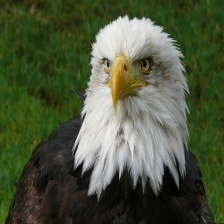

In [33]:
img_test6

lo mas probable la razon por la cual este no entrega un resultado bueno es porque en sí, no debe ni estar presentado como una de las especies entrenadas y está simplemente buscando en las 20 alguna que sea similar y nos da el Alpine Chough

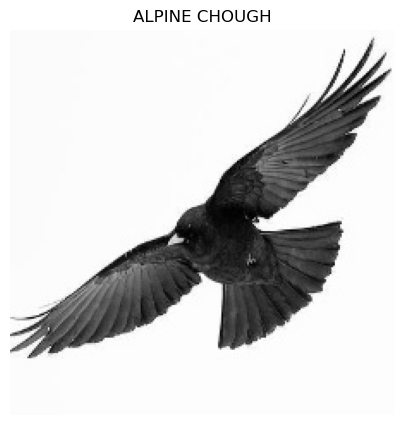

In [34]:
especie = "ALPINE CHOUGH" 

img_path = next((TRAIN_DIR / especie).glob("*.jpg"))
img = Image.open(img_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(especie, fontsize=12)
plt.axis("off")
plt.show()